# 16 — Framing, viewports and locator insets

A map has to answer "where am I?" before it can say anything else. This notebook covers the three tools for
that: `set_bounds` to frame the view, `viewport` to read the framing back as a value, and `inset` /
`mark_extent` to show a detail map's place in the wider world.

API: [`Map.set_bounds`](../reference/static_map.md), [`Map.inset`](../reference/static_map.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`:
> WorldPop population grids, OpenStreetMap roads, GBIF bird occurrences and geoBoundaries admin
> polygons. `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits two levels up: docs/examples -> repo root.
DATA = Path("../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany.
UTM32 = 25832


## The data

A real nested pair: the **WorldPop** population grid and **geoBoundaries** states for the whole of Germany, and
the 2,320 **OpenStreetMap** road centrelines for Heidelberg inside it. The wide layer gives context, the narrow
one is the detail — which is exactly the situation insets exist for.

In [2]:
pop = Dataset.read_file(str(DATA / "germany_pop_2020_1km.tif"))
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
roads = FeatureCollection.read_file(str(DATA / "heidelberg_roads.geojson"))
print(f"Germany: {pop.rows}x{pop.columns} cells, {len(states)} states")
print(f"Heidelberg: {len(roads)} road centrelines")

Germany: 934x1100 cells, 16 states
Heidelberg: 2320 road centrelines


## Framing with `set_bounds`

`set_bounds` takes `[west, south, east, north]` **in display-CRS units** and frames the figure on it. Without
it, a map shows whatever its layers happen to span — fine for one raster, wrong as soon as two figures need to be
comparable.

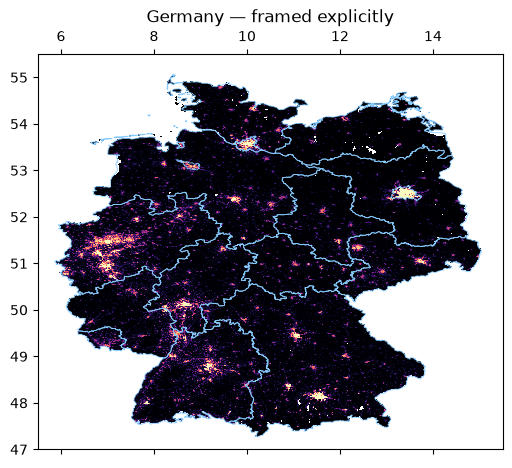

In [3]:
m = Map(crs=4326, figsize=(6, 7))
m.field(pop, cmap="magma", vmin=0, vmax=2000)
m.polygons(states, edgecolor="#88ccff", linewidth=0.6)
m.set_bounds([5.5, 47.0, 15.5, 55.5])
m.set_title("Germany — framed explicitly")
m.fig;

Two maps built with the same `set_bounds` are directly comparable whatever they draw, which is why framing
belongs in the figure's description rather than being a side effect of the data.

The units point matters: those numbers are degrees because the display CRS is EPSG:4326. The same call on a
UTM map takes metres.

## `padding` — framing on the data, with room to breathe

With no bounds, `set_bounds` frames on **everything the map draws**. `padding` adds a fractional margin so
features do not touch the frame edge.

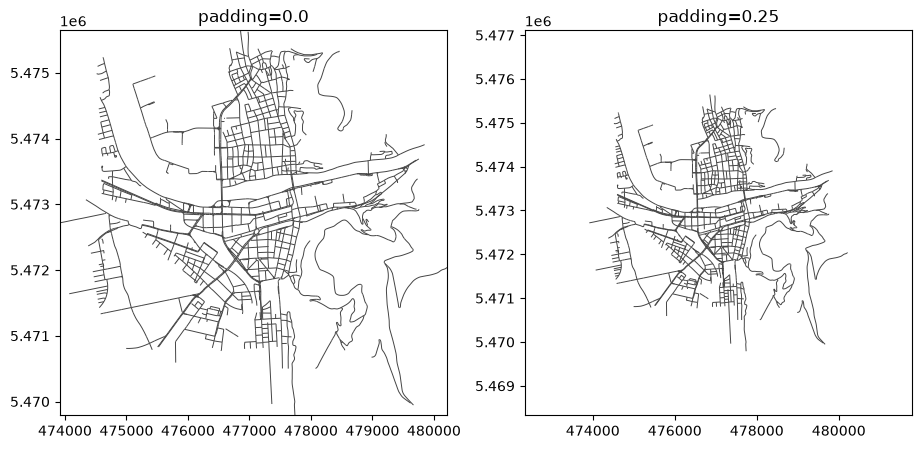

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, pad in zip(axes, (0.0, 0.25)):
    panel = Map(ax=ax, crs=UTM32)
    panel.lines(roads, color="#444444", width=0.7)
    panel.set_bounds(padding=pad)
    ax.set_title(f"padding={pad}")
fig;

On the left the network touches the frame; on the right a quarter-extent margin gives it air. Padding is the
difference between a plot and a map a reader can orient in.

## Reading the framing back — `viewport`

`viewport` returns the framing **as a value**: the CRS, the bounds, whether the map is a globe. It is how code
asks a figure where it is looking instead of inferring it from the axes.

crs:    4326
bounds: Bounds(xmin=5.5, ymin=47.0, xmax=15.5, ymax=55.5, crs=4326)
globe:  False


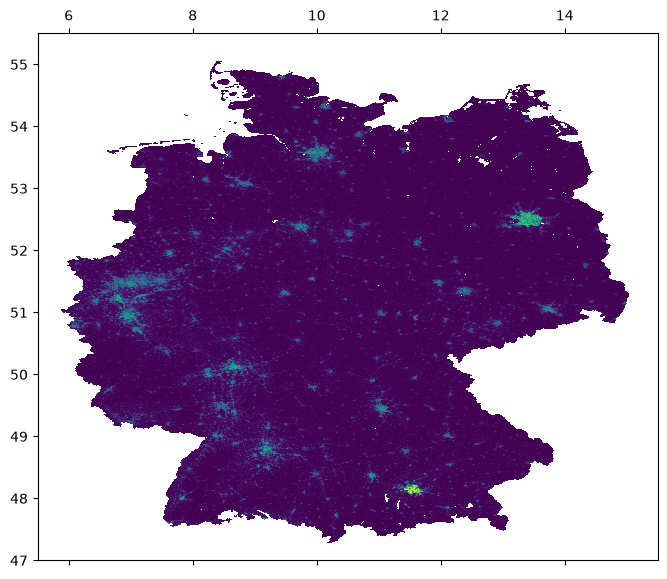

In [5]:
framed = Map(crs=4326).field(pop).set_bounds([5.5, 47.0, 15.5, 55.5])
vp = framed.viewport
print("crs:   ", vp.crs)
print("bounds:", vp.bounds)
print("globe: ", vp.globe)

An unframed map reports `bounds=None` — it has not been told where to look, so there is nothing to report.

unframed bounds: None


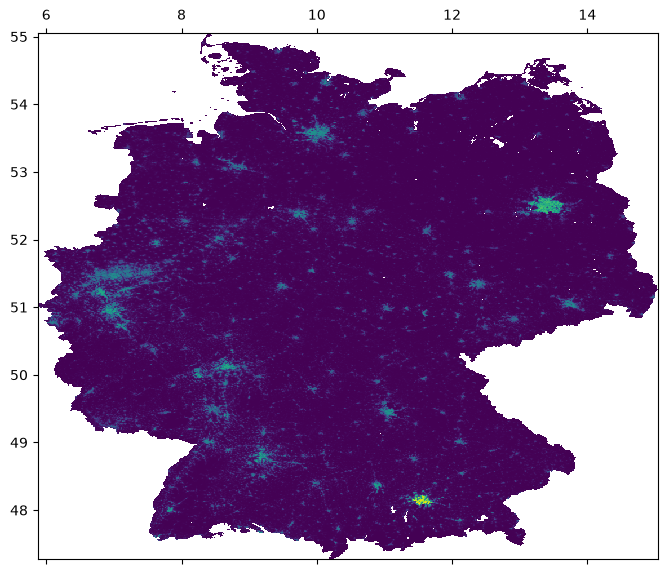

In [6]:
print("unframed bounds:", Map(crs=4326).field(pop).viewport.bounds)

## Locator insets — `inset`

A detail map is useless without context. `inset()` adds a small map in the corner showing where the main map's
extent sits in a wider area, with that extent drawn on it — the standard atlas locator.

| argument | meaning | typical value |
|---|---|---|
| `position` | which corner | `"upper right"` (default), `"lower left"`, … |
| `size` | inset size as a fraction of the axes | `0.28` default |
| `extent` | what the inset itself shows | `None` = a sensible wider area |
| `reference` | reference layers drawn on the inset | `("land", "coastlines")` |
| `crs` / `globe` | the inset's own projection | `None` = the parent's |

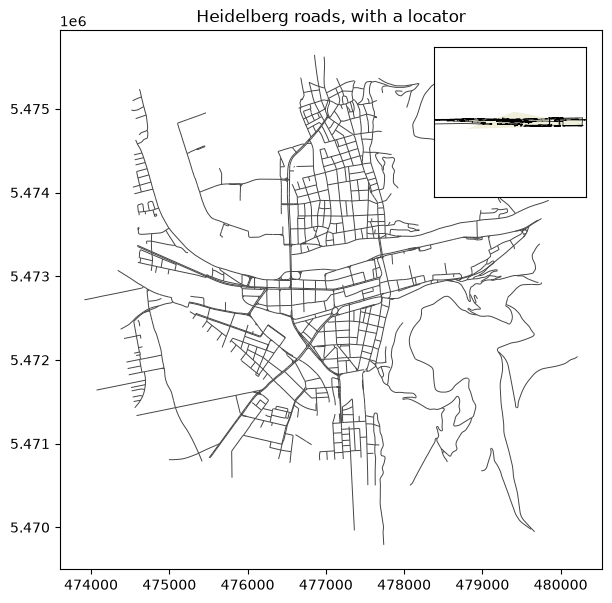

In [7]:
detail = Map(crs=UTM32, figsize=(7, 7))
detail.lines(roads, color="#444444", width=0.7)
detail.set_bounds(padding=0.05)
detail.inset()
detail.set_title("Heidelberg roads, with a locator")
detail.fig;

The corner inset carries land and coastlines plus an outline of the main map's extent. A reader who has never
heard of Heidelberg now knows they are looking at south-west Germany.

## Putting the locator on a globe

The inset takes its own `crs` and `globe`, and the globe variant is the most useful: a flat detail map with a
globe locator removes any doubt about which part of the world you are in.

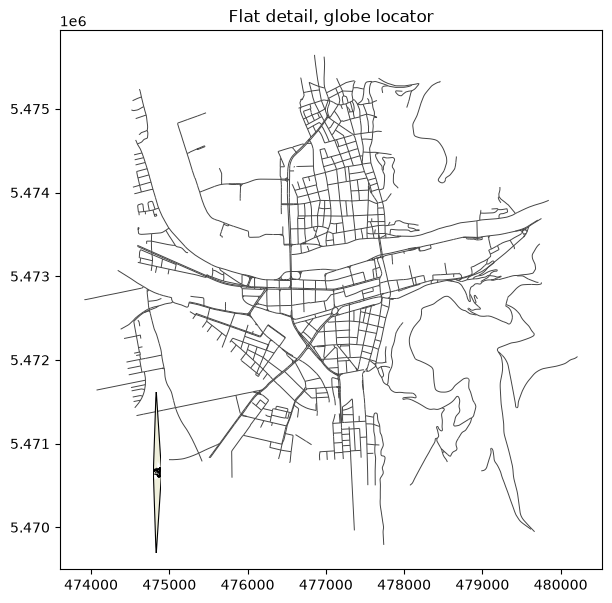

In [8]:
detail = Map(crs=UTM32, figsize=(7, 7))
detail.lines(roads, color="#444444", width=0.7)
detail.set_bounds(padding=0.05)
detail.inset(globe=True, position="lower left", size=0.3)
detail.set_title("Flat detail, globe locator")
detail.fig;

The locator is reached afterwards through the `locator` property, so it can be decorated like any other map.

In [9]:
print("locator is a:", type(detail.locator).__name__)
print("locator layers:", detail.locator.layer_ids)

locator is a: Map
locator layers: ['land-1', 'coastlines-1', 'custom-1']


## Cross-referencing two maps — `mark_extent`

`inset` builds its own small map. When you already have **two** maps and want one to show the other's extent,
`mark_extent` draws that extent as an outline on the receiving map. Here the real population map of Germany marks
where the Heidelberg road map is looking.

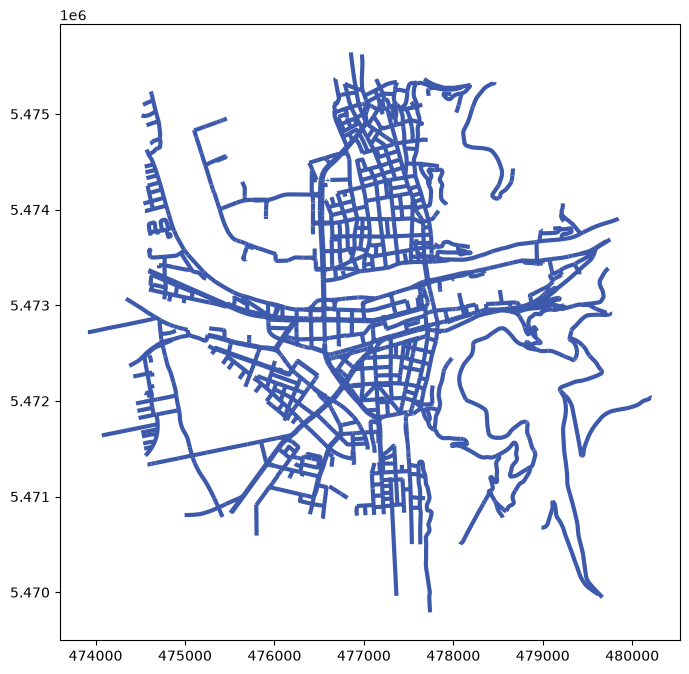

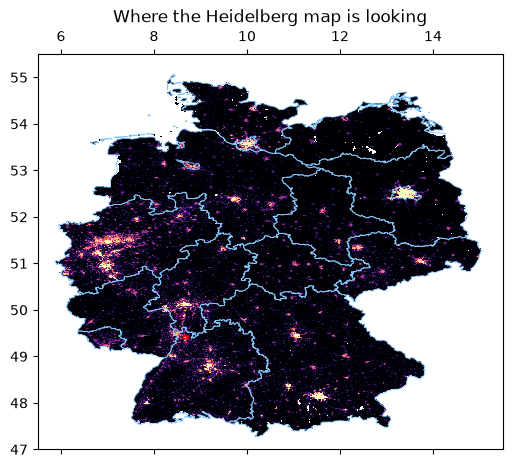

In [10]:
zoom = Map(crs=UTM32).lines(roads).set_bounds(padding=0.05)

context = Map(crs=4326, figsize=(6, 7))
context.field(pop, cmap="magma", vmin=0, vmax=2000)
context.polygons(states, edgecolor="#88ccff", linewidth=0.6)
context.set_bounds([5.5, 47.0, 15.5, 55.5])
context.mark_extent(zoom)
context.set_title("Where the Heidelberg map is looking")
context.fig;

The small rectangle on the Rhine-Neckar conurbation is the `zoom` map's extent. This is the two-figure form of a
locator: a detail-and-context pair where the context panel marks what the detail panel shows. Lay both out in one
figure with [`17_multi_panel_figures`](17_multi_panel_figures.ipynb).

## Takeaway

- `set_bounds([w, s, e, n])` frames the map, **in display-CRS units**; with no argument it frames on the data,
  and `padding` adds margin.
- Explicit framing is what makes two figures comparable.
- `viewport` reads the framing back as a value — `bounds` is `None` until the map has been framed.
- `inset()` adds a self-contained locator; `globe=True` makes it unmistakable, and `locator` reaches it after.
- `mark_extent(other)` draws one map's extent on another, for detail-and-context pairs.

Next: [`17_multi_panel_figures`](17_multi_panel_figures.ipynb).